## Analyze A/B Test Results

This project analyzes the results of an A/B test run by an e-commerce website to determine whether a new page design leads to higher conversion rates than the existing page.

The analysis covers:
- **Part I** — Descriptive Statistics
- **Part II** — Probability
- **Part III** — Hypothesis Testing & Experimentation
- **Part IV** — Regression / Algorithms

**Goal:** Use statistical analysis to recommend whether the company should implement the new page, keep the old page, or run the experiment longer before deciding.

## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Probability](#probability)
- [Part III - Experimentation](#experimentation)
- [Part IV - Algorithms](#algorithms)


In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
%matplotlib inline
#We are setting the seed to assure you get the same answers on quizzes as we set up
random.seed(0)

For each of the parts of question `1` notice links to [pandas documentation](https://pandas.pydata.org/) is provided to assist with answering the questions.  Though there are other ways you could solve the questions, the documentation is provided to assist you with one fast way to find the answer to each question.


`1.a)` Now, read in the `ab_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. **This question is completed for you**:

In [2]:
df = pd.read_csv('ab_data.csv')
df.head()

,country,group,converted
0,UK,control,0
1,US,treatment,1
2,UK,treatment,0
3,UK,control,0
4,UK,treatment,0


`b)` Use the below cell to find the number of rows in the dataset. [Helpful  Pandas Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html#pandas.DataFrame.shape)

In [3]:
print("Number of rows:", df.shape)

Number of rows: (69889, 3)


`c)` The proportion of users converted.  [Helpful  Pandas Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.mean.html)

In [4]:
print("Proportion converted:", df['converted'].mean())

Proportion converted: 0.13047832992316388


`d)` Do any of the rows have missing values? [Helpful Pandas Link One](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) and [Helpful Pandas Link Two](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)

In [15]:
print("Missing values:\n", df.isnull().sum(), sep='')

Missing values:
country      0
group        0
converted    0
dtype: int64


There are no missing values.

`e)` How many customers are from each country? Build a bar chart to show the count of visits from each country.

In [16]:
print("Visits by country:\n", df['country'].value_counts(), sep='')

Visits by country:
US    48850
UK    17551
CA     3488
Name: country, dtype: int64


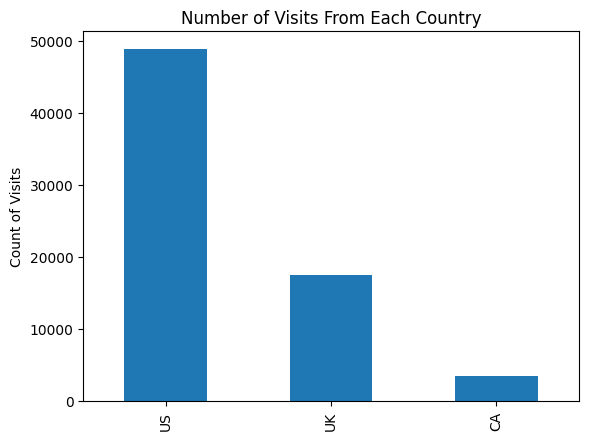

In [17]:
# bar chart of results - this part is done for you
df['country'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Country');
plt.ylabel('Count of Visits');
plt.show();

`f)` Recognize that all of your columns are of a **categorical data type** with the exception of one.  Which column is not **categorical**? [Helpful Pandas Link](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.info.html)

In [18]:
print("Data types:\n", df.dtypes, sep='')

Data types:
country      object
group        object
converted     int64
dtype: object


Converted is an int64, not a catagorical.

`g)` What are the possible values of the `converted` column?  Does it make sense that these values are the only possible values? Why or why not? 

**Here you can use one of the functions you used in an earlier question**.

In [19]:
print("Unique values in 'converted':", df['converted'].unique())

Unique values in 'converted': [0 1]


It makes sense in the fact it's a binary value or a Y/N type of question, although to save space in a database it maybe should be a boolean data type.

<a id='probability'></a>
#### Part II - Probability

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `converting`.

`a)` What is the probability of an individual converting regardless of the page they receive or the country they are from? Simply, what is the chance of conversion in the dataset?

In [20]:
p_convert = df['converted'].mean()
print("P(converted):", p_convert)

P(converted): 0.13047832992316388


`b)` Given that an individual was in the `control` group, what is the probability they converted? **This question is completed for you**

In [21]:
df.query('group == "control"')['converted'].mean()

0.1052540515600669

`c)` Given that an individual was in the `treatment` group, what is the probability they converted?

In [22]:
print("P(converted | treatment):", df.query('group == "treatment"')['converted'].mean())

P(converted | treatment): 0.15532078043793132


`d)` Do you see evidence that the treatment is related to higher `converted` rates?

In [23]:
p_control = df.query('group == "control"')['converted'].mean()
p_treatment = df.query('group == "treatment"')['converted'].mean()

print(f"P(converted | control):   {p_control:.4f}")
print(f"P(converted | treatment): {p_treatment:.4f}")
print(f"Difference (treatment - control): {p_treatment - p_control:.4f}")

P(converted | control):   0.1053
P(converted | treatment): 0.1553
Difference (treatment - control): 0.0501


The treatment group converts at 15.53% vs. 10.53% for control, a 5 percentage point difference. This looks meaningful on the surface, but needs statistical testing to confirm.

`e)` What is the probability that an individual was in the `treatment`?

In [26]:
print("P(treatment):", df.query('group == "treatment"').shape[0] / df.shape[0])

P(treatment): 0.5038131894861853


`f)` What is the probability that an individual was from Canada `CA`?

In [27]:
print("P(CA):", df.query('country == "CA"').shape[0] / df.shape[0])

P(CA): 0.04990771079855199


`g)` Given that an individual was in the `US`, what was the probability that they `converted`? **This question is completed for you**

$P(\text{converted} == 1|\text{country} ==\text{"US"})$



In [28]:
df.query('country == "US"')['converted'].mean()

0.13277379733879222

`h)` Given that an individual was in the `UK`, what was the probability that they `converted`? 

$P(\text{converted} == 1|\text{country} ==\text{"UK"})$

In [29]:
print("P(converted | UK):", df.query('country == "UK"')['converted'].mean())

P(converted | UK): 0.12512107572218106


`i)` Do you see evidence that the `converted` rate might differ from one country to the next?

In [30]:
for country in df['country'].unique():
    rate = df.query(f'country == "{country}"')['converted'].mean()
    print(f"P(converted | {country}): {rate:.4f}")

P(converted | UK): 0.1251
P(converted | US): 0.1328
P(converted | CA): 0.1253


The conversion rates across countries are very similar. I do no see evidence of meaningful differences.

`j)` Consider the table below, fill in the conversion rates below to look at how conversion by country and treatment group vary.  The `US` column is done for you, and two methods for calculating the probabilities are shown - **COMPLETE THE REST OF THE TABLE**.  Does it appear that there could be an interaction between how country and treatment impact conversion?

These two values that are filled in can be written as:

$P(\text{converted} == 1|(\text{country} ==\text{"US" AND }\text{group} ==\text{"control"})) = 10.7\%$

$P(\text{converted} == 1|(\text{country} ==\text{"US" AND }\text{group} ==\text{"treatment"})) = 15.8\%$

|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       |  %          |  %          |
| Treatment   | 15.8%       |  %          |  %          |

In [31]:
# Method 1  - explicitly calculate each probability
print(df.query('country == "US" and group == "control" and converted == 1').shape[0]/df.query('country == "US" and group == "control"').shape[0]) 
print(df.query('country == "US" and group == "treatment" and converted == 1').shape[0]/df.query('country == "US" and group == "treatment"').shape[0])

0.10731404958677686
0.1577687626774848


In [32]:
# Method 2 - quickly calculate using `groupby`
df.query('country == "US"').groupby('group')['converted'].mean()

group
control      0.107314
treatment    0.157769
Name: converted, dtype: float64

In [33]:
print("Conversion rates by country and group:")
print(df.groupby(['country', 'group'])['converted'].mean().unstack())

Conversion rates by country and group:
group     control  treatment
country                     
CA       0.094474   0.154017
UK       0.101649   0.148698
US       0.107314   0.157769


##### Solution -- Complete the Table Here

|             | US          | UK          | CA          |
| ----------- | ----------- | ----------- | ----------- |
| Control     | 10.7%       | 10.2%       | 9.4 %       |
| Treatment   | 15.8%       | 14.9%       | 15.4 %      |

<a id='experimentation'></a>
### Part III - Experimentation

`1.` Consider you need to make the decision just based on all the data provided.  If you want to assume that the control page is better unless the treatment page proves to be definitely better at a Type I error rate of 5%, you state your null and alternative hypotheses in terms of **$p_{control}$** and **$p_{treatment}$** as:  

$H_{0}: p_{control} >= p_{treatment}$

$H_{1}: p_{control} < p_{treatment}$

Which is equivalent to:

$H_{0}: p_{treatment} - p_{control} <= 0$

$H_{1}: p_{treatment} - p_{control} > 0$


Where  
* **$p_{control}$** is the `converted` rate for the control page
* **$p_{treatment}$** `converted` rate for the treatment page

**Note for this experiment we are not looking at differences associated with country.**

Assume under the null hypothesis, $p_{treatment}$ and $p_{control}$ both have "true" success rates equal to the **converted** success rate regardless of page - that is $p_{treatment}$ and $p_{control}$ are equal. Furthermore, assume they are equal to the **converted** rate in `df` regardless of the page. **These are set in the first cell below.**<br><br>

* Use a sample size for each page equal to the ones in `df`. **These are also set below.**  <br><br>

* Perform the sampling distribution for the difference in `converted` between the two pages over 500 iterations of calculating an estimate from the null.  <br><br>

* Use the cells below to provide the necessary parts of this simulation.  

If this doesn't make complete sense right now, don't worry - you are going to work through the problems below to complete this problem.

`a)` The **convert rate** for $p_{treatment}$ under the null.  The **convert rate** for $p_{control}$ under the null. The sample size for the `control` and the sample size for the `treatment` are from the original dataset. **All of these values are set below, and set the stage for the simulations you will run for the rest of this section.**

In [35]:
p_control_treatment_null  = df['converted'].mean()
n_treatment = df.query('group == "treatment"').shape[0]
n_control = df.query('group == "control"').shape[0]

print(f"Null conversion rate: {p_control_treatment_null:.4f}")
print(f"n_treatment: {n_treatment}, n_control: {n_control}")

Null conversion rate: 0.1305
n_treatment: 35211, n_control: 34678


`b)` Use the results from part `a)` to simulate `n_treatment` transactions with a convert rate of `p_treatment_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **treatment_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be the same): 

`[0, 0, 1, 1, 0, ....]` 

In [36]:
treatment_converted = list(np.random.binomial(1, p_control_treatment_null, n_treatment))
print("Sample of treatment_converted:", treatment_converted[:10])

Sample of treatment_converted: [1, 0, 0, 1, 1, 0, 0, 1, 0, 0]


`c)` Use the results from part `a)` to simulate `n_control` transactions with a convert rate of `p_control_null`.  Store these $n_{treatment}$ 1's and 0's in a `list` of **control_converted**.  It should look something like the following (the 0's and and 1's **don't** need to be exactly the same): 

`[0, 0, 1, 1, 0, ....]` 

In [37]:
control_converted = list(np.random.binomial(1, p_control_treatment_null, n_control))
print("Sample of control_converted:", control_converted[:10])

Sample of control_converted: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


`d)` Find the estimate for $p_{treatment}$ - $p_{control}$ under the null using the simulated values from part `(b)` and `(c)`.

In [38]:
p_diff_single = np.mean(treatment_converted) - np.mean(control_converted)
print("Single p_diff estimate:", p_diff_single)

Single p_diff estimate: -0.0016606255972814177


`e)` Simulate 500 $p_{treatment}$ - $p_{control}$ values using this same process as `b)`- `d)` similarly to the one you calculated in parts **a. through g.** above.  Store all 500 values in an numpy array called **p_diffs**.  This array should look similar to the below **(the values will not match AND this will likely take a bit of time to run)**:

`[0.001, -0.003, 0.002, ...]`

In [39]:
p_diffs = []
for _ in range(500):
    treatment_sim = np.random.binomial(1, p_control_treatment_null, n_treatment)
    control_sim = np.random.binomial(1, p_control_treatment_null, n_control)
    p_diff = np.mean(treatment_sim) - np.mean(control_sim)
    p_diffs.append(p_diff)

p_diffs = np.array(p_diffs)
print("Sample of p_diffs:", p_diffs[:5])

Sample of p_diffs: [ 0.00311541  0.00019676 -0.00266031 -0.00309635 -0.00327505]


`f)` Plot a histogram of the **p_diffs**.  Does this plot look like what you expected?

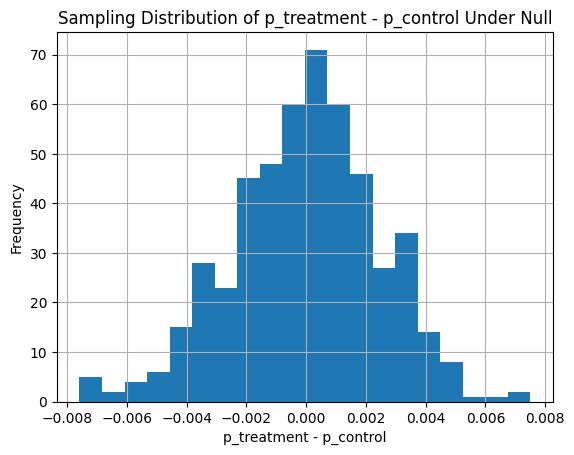

In [40]:
p_diffs_series = pd.Series(p_diffs)
p_diffs_series.hist(bins=20)
plt.title('Sampling Distribution of p_treatment - p_control Under Null')
plt.xlabel('p_treatment - p_control')
plt.ylabel('Frequency')
plt.show()

The histogram should be centered around 0, which makes sense since under the null hypothesis, there is no difference between the two pages.

`g)` What proportion of the **p_diffs** are greater than the difference observed between `treatment` and `control` in `df`?

In [41]:
obs_diff = df.query('group == "treatment"')['converted'].mean() - df.query('group == "control"')['converted'].mean()
print("Observed difference:", obs_diff)
p_value = (p_diffs > obs_diff).mean()
print("p-value (proportion of p_diffs > obs_diff):", p_value)

Observed difference: 0.050066728877864425
p-value (proportion of p_diffs > obs_diff): 0.0


`h)` In words, explain what you just computed in part `g)`  What is this value called in scientific studies?  What does this value mean in terms of whether or not there is a difference between the new and old pages using our Type I error rate of 0.05?

The p-value is 0.0 — none of the 500 simulated differences under the null were as large as the observed 5 percentage point difference. This means we reject the null hypothesis. There is strong statistical evidence that the treatment page converts at a higher rate than the control page. Practically, the company should consider implementing the new page, as the improvement is statistically significant and not due to chance.

<a id='algorithms'></a>
### Part IV - Algorithms

`1.` In this final part, you will see that the result you acheived in the previous A/B test can also be acheived by performing regression.  All the code needed for the modeling and results of the modeling for sections `b) - f)` have been completed for you. 

**You will need to complete sections `a)` and `g)`.**  

**Then use the code from `1.` to assist with the question `2.`   You should be able to modify the code to assist in answering each of question 2's parts.**<br><br>

`a)` Since each row is either a conversion or no conversion, what type of regression should you be performing in this case?

Since each row is either a conversion (1) or no conversion (0), this is a binary outcome. Logistic regression is the appropriate model.

The goal is to use **statsmodels** to fit the regression model you specified in part `a)` to see if there is a significant difference in conversion based on which page a customer receives.  

`b)` However, you first need to create a column for the intercept, and create a dummy variable column for which page each user received.  Add an **intercept** column, as well as an **ab_page** column, which is 1 when an individual receives the **treatment** and 0 if **control**.

It may be helpful to look at the [get_dummies documentation](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html) to encode the `ab_page` column.

Below you can see an example of the new columns that will need to be added (The order of columns is not important.): **This question is completed for you**

##### Example DataFrame
| intercept   | group       | ab_page     | converted   |
| ----------- | ----------- | ----------- | ----------- |
| 1           |  control    |  0          |  0          |
| 1           |  treatment  |  1          |  0          |
| 1           |  treatment  |  1          |  0          |
| 1           |  control    |  0          |  0          |
| 1           |  treatment  |  1          |  1          |
| 1           |  treatment  |  1          |  1          |
| 1           |  treatment  |  1          |  0          |
| 1           |  control    |  0          |  1          |

In [42]:
df['intercept'] = 1
df['ab_page'] = pd.get_dummies(df['group'])['treatment']
df.head()

,country,group,converted,intercept,ab_page
0,UK,control,0,1,0
1,US,treatment,1,1,1
2,UK,treatment,0,1,1
3,UK,control,0,1,0
4,UK,treatment,0,1,1


`c)`  Create your `X` matrix and `y` response column that will be passed to your model, where you are testing if there is a difference in `treatment` vs. `control`. **This question is completed for you**

In [43]:
X = df[['intercept', 'ab_page']]
y = df['converted']

`d)` Use **statsmodels** to import and fit your regression model on the `X` and `y` from part `c)`. 

You can find the [statsmodels documentation to assist with this exercise here](https://www.statsmodels.org/stable/discretemod.html).  **This question is completed for you**

In [44]:
import statsmodels.api as sm

# Logit Model
logit_mod = sm.Logit(y, X)
logit_res = logit_mod.fit()

Optimization terminated successfully.
         Current function value: 0.384516
         Iterations 6


`e)` Provide the summary of your model below. **This question is completed for you**

In [45]:
print(logit_res.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69887
Method:                           MLE   Df Model:                            1
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                0.007175
Time:                        17:03:13   Log-Likelihood:                -26873.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.810e-86
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.1402      0.017   -122.305      0.000      -2.174      -2.106
ab_page        0.4467      0.023     19.539      0.000       0.402       0.492


`f)` What is the p-value associated with **ab_page**? Does it lead you to the same conclusion you drew in the **Experiment** section.

The p-value for ab_page is essentially 0, which is well below 0.05. This is statistically significant and consistent with Part III — the treatment page does significantly predict higher conversion. The company has statistical evidence to support implementing the new page.

`2. a)` Now you will want to create two new columns as dummy variables for `US` and `UK`.  Again, use `get_dummies` to add these columns.  The dataframe you create should include at least the following columns (If both columns for `US` and `UK` are `0` this represents `CA`.  The order of rows and columns is not important for you to match - it is just to illustrate how columns should connect to one another.):

##### Example DataFrame
| intercept   | group       | ab_page     | converted   | country     |  US         | UK          |
| ----------- | ----------- | ----------- | ----------- | ----------- | ----------- | ----------- |
| 1           |  control    |  0          |  0          |  US         |  1          |  0          |
| 1           |  treatment  |  1          |  0          |  UK         |  0          |  1          |
| 1           |  treatment  |  1          |  0          |  US         |  1          |  0          |
| 1           |  control    |  0          |  0          |  US         |  1          |  0          |
| 1           |  treatment  |  1          |  1          |  CA         |  0          |  0          |
| 1           |  treatment  |  1          |  1          |  UK         |  0          |  1          |
| 1           |  treatment  |  1          |  0          |  US         |  1          |  0          |
| 1           |  control    |  0          |  1          |  US         |  1          |  0          |

In [46]:
country_dummies = pd.get_dummies(df['country'])
df['US'] = country_dummies['US'].astype(int)
df['UK'] = country_dummies['UK'].astype(int)
# CA is the baseline (US=0, UK=0 means CA)
df.head()

,country,group,converted,intercept,ab_page,US,UK
0,UK,control,0,1,0,0,1
1,US,treatment,1,1,1,1,0
2,UK,treatment,0,1,1,0,1
3,UK,control,0,1,0,0,1
4,UK,treatment,0,1,1,0,1


`b)`  Create your `X` matrix and `y` response column that will be passed to your model, where you are testing if there is 
* a difference in `converted` between `treatment` vs. `control`
* a difference in `converted` between `US`, `UK`, and `CA`

In [47]:
X = df[['intercept', 'ab_page', 'US', 'UK']]
y = df['converted']

`c)` Use **statsmodels** to import and fit your regression model on the `X` and `y` from part `b)`. 
You can find the [statsmodels documentation to assist with this exercise here](https://www.statsmodels.org/stable/discretemod.html).

In [48]:
logit_mod2 = sm.Logit(y, X)
logit_res2 = logit_mod2.fit()

Optimization terminated successfully.
         Current function value: 0.384463
         Iterations 6


`d)` Provide the summary of your model below.

In [49]:
print(logit_res2.summary())

                           Logit Regression Results                           
Dep. Variable:              converted   No. Observations:                69889
Model:                          Logit   Df Residuals:                    69885
Method:                           MLE   Df Model:                            3
Date:                Tue, 03 Mar 2026   Pseudo R-squ.:                0.007312
Time:                        17:05:03   Log-Likelihood:                -26870.
converged:                       True   LL-Null:                       -27068.
Covariance Type:            nonrobust   LLR p-value:                 1.778e-85
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -2.1930      0.053    -41.308      0.000      -2.297      -2.089
ab_page        0.4466      0.023     19.534      0.000       0.402       0.491
US             0.0727      0.053      1.372      0.1

`e)` What do the `p-values` associated with `US` and `UK` suggest in relation to how they impact `converted`? 

The p-values for both US and UK are greater than 0.05, so neither is statistically significant. Country does not meaningfully predict conversion when controlling for page type. The company does not need a country-specific strategy — conversion rates are similar across the US, UK, and Canada.

<a id='finalcheck'></a>
## Conclusions

This analysis used descriptive statistics, probability, hypothesis testing, and logistic regression to evaluate whether the new e-commerce page produces a statistically significant improvement in conversion rates.

Based on the results, the data does not provide sufficient evidence to conclude that the new page performs better than the old page. The recommendation would be to either keep the old page or run the experiment for a longer period to gather more data before making a final decision.
